## 1. Project Overview

## 1A. Project Objective

Money laundering is the process of disguising the origins of illicit funds so they appear to come from legitimate sources, typically through a sequence of placement, layering, and integration steps. Examples of predicate crimes that generate illicit proceeds requiring laundering include bribery, human trafficking, drug trafficking, sanctions evasion, and wildlife trafficking.

**FinCEN (Financial Crimes Enforcement Network)** is a bureau of the U.S. Department of the Treasury responsible for collecting and analyzing financial transaction data to combat money laundering, terrorist financing, and other financial crimes. One of FinCEN’s key responsibilities is maintaining the national database of Suspicious Activity Reports (SARs).

A **Suspicious Activity Report (SAR)** is filed when a regulated entity detects activity that may indicate money laundering, fraud, terrorist financing, structuring, identity theft, or other forms of financial crime. SAR filing obligations apply not only to traditional financial institutions such as banks and credit unions, but also to casinos, money transmitters, check cashers, currency exchangers, prepaid card providers, broker‑dealers, mutual funds, insurance companies, and certain real estate professionals. SARs do not accuse a customer of wrongdoing; instead, they alert authorities to unusual patterns that warrant further review. These reports are used by a wide range of federal, state, and local agencies, including IRS‑Criminal Investigation (IRS‑CI), the Drug Enforcement Administration (DEA), the Federal Bureau of Investigation (FBI), Homeland Security Investigations (HSI), the U.S. Secret Service, state attorneys general, local law enforcement, and regulatory bodies such as the Office of the Comptroller of the Currency (OCC), the Federal Reserve, the Federal Deposit Insurance Corporation (FDIC), and FinCEN itself. These agencies rely on SARs to identify emerging threats, support criminal investigations, and enforce compliance with anti‑money‑laundering laws.

This project examines patterns in SAR filings across U.S. states and explores how these patterns relate to the presence and distribution of Money Services Businesses (MSBs). The analysis integrates three datasets—FinCEN SAR Statistics, the MSB Registrant Database, and a benchmark fraud dataset—to perform data cleaning, exploratory data analysis, and an initial statistical model quantifying the relationship between MSB density and SAR activity.

## 1B. Project Structure
1. Project Overview
2. Import Libraries
3. Load Raw Datasets
4. Data Cleaning
5. Exploratory Data Analysis
6. Regression Model
7. Scope & Success Criteria
8. Conclusion / Next Steps


## 2. Import Libraries
This section imports core Python libraries ued throughout the analysis.
Each library plays a specific role in data manipulation

In [1]:
# 2.1 Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.2 Configure visualization style
sns.set(style="whitegrid")

## 3. Load Raw Datasets

This section loads the three primary datasets used in the analysis:

FinCEN SAR Statistics — aggregated Suspicious Activity Report filings by state, industry, and time period.

MSB Registrant Database — a registry of Money Services Businesses operating across U.S. states and territories.

Fraud Dataset Benchmark (FDB) — a synthetic transaction‑level dataset used for exploratory comparison and fraud‑related feature analysis.

All raw files are stored in the data/raw/ directory and are imported in their original form before any cleaning or transformation. Initial .head(), .info(), and .describe() outputs are included to verify schema, structure, and data quality.


In [2]:
# 3.1 Load SAR dataset
sar = pd.read_csv("data/raw/sar_stats.csv")
sar.head()
sar.info()
sar.describe(include = "all")

# 3.2 Load MSB dataset
msb = pd.read_csv("data/raw/msb_registrants.csv")
msb.columns = msb.columns.str.lower().str.replace(" ", "_")
msb.head
msb.info()
msb.describe(include = "all")

# 3.3 Load Fraud dataset
fraud = pd.read_csv("data/raw/fraud_dataset.csv")
fraud.columns = fraud.columns.str.lower().str.replace(" ", "_")
fraud.head()
fraud.info()


C:\Users\djgib\AppData\Local\Temp\ipykernel_30028\4145689594.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  sar = pd.read_csv("data/raw/sar_stats.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169140 entries, 0 to 169139
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Year Month  169140 non-null  object
 1   State       169140 non-null  object
 2   Industry    169140 non-null  object
 3   Regulator   169140 non-null  object
 4   Product     169140 non-null  object
 5   Instrument  169140 non-null  object
 6   Count       169140 non-null  object
dtypes: object(7)
memory usage: 9.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36704 entries, 0 to 36703
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   legal_name                                 36697 non-null  object 
 1   dba_name                                   13916 non-null  object 
 2   street_address                             36672 non-null  object 
 3   city   

## 3A. Data Overview
This project integrates three datasets sourced from FinCEN and synthetic benchmarking data. Each dataset contributes a different perspective on financial activity, regulatory reporting, and potential indicators of financial crime. A brief description of each dataset is provided below.

1. FinCEN SAR Statistics Dataset
This dataset contains aggregated Suspicious Activity Report (SAR) filings submitted by regulated financial institutions. Records are grouped by:

-Year-Month

-State

-Industry (e.g., Depository Institution, MSB, Securities/Futures)

-Regulator

-Product (e.g., deposit accounts, debit cards, credit cards)

-Instrument

-Count (number of SAR filings)

This dataset provides the primary dependent variable for the analysis: total SAR filings by state. It enables trend analysis across time, industries, and product categories.

2. MSB Registrant Database
The MSB dataset includes all Money Services Businesses registered with FinCEN. Each record contains:

-Legal name / DBA name

-Business address (street, city, state, ZIP)

-MSB activities (e.g., money transmission, check cashing, currency exchange)

-States of operation

-Number of branches

-Registration and authorization dates

-This dataset is used to compute MSB density by state, which serves as the primary independent variable in the regression model.

3. Fraud Dataset Benchmark (FDB)
The Fraud Dataset Benchmark is a synthetic transaction‑level dataset used for exploratory comparison. It includes:

-Transaction amount, type, timestamp, and location
-Account balance and device type
-Merchant category
-Risk score and fraud label
-Behavioral features (e.g., daily transaction count, failed transactions, card age)

Although not directly used in the regression model, this dataset provides context for understanding fraud‑related patterns and complements the broader financial crime analysis.

## 3B. Data Dictionary

### FinCEN SAR Statistics Dataset

| Column       | Description                                                        |
|--------------|--------------------------------------------------------------------|
| year_month   | Reporting period (monthly), converted to datetime.                 |
| state        | U.S. state or territory where the SAR was filed.                   |
| industry     | Industry category of the reporting institution.                    |
| regulator    | Primary regulator overseeing the institution.                      |
| product      | Financial product associated with the suspicious activity.         |
| instrument   | Instrument or channel used in the transaction.                     |
| count        | Number of SAR filings for that state/industry/product/month.       |
| year         | Extracted year used for annual aggregation.                        |


### MSB Registrant Database

| Column                     | Description                                                                 |
|----------------------------|-----------------------------------------------------------------------------|
| legal_name                 | Registered legal name of the MSB.                                           |
| dba_name                   | Doing business as name, if applicable.                                    |
| street_address             | Street address of the MSB.                                                  |
| city                       | City where the MSB is located.                                              |
| state                      | U.S. state where the MSB is registered or operating.                        |
| zip                        | ZIP code of the MSB location.                                               |
| msb_activities             | Types of MSB services offered (e.g., money transmission, check cashing).    |
| states_of_msb_activities   | States where the MSB is authorized to operate.                              |
| all_states_&_territories   | Indicator for nationwide or multi-state operations.                         |
| foreign_location           | Foreign location information, if applicable.                                |
| #_of_branches              | Number of branch locations.                                                 |
| auth_sign_date             | Date the MSB registration was authorized.                                   |
| received_date              | Date the registration was received by FinCEN.                               |
| age_years                  | Derived variable representing MSB registration age in years.                |


### Fraud Dataset Benchmark (FDB)

| Column                       | Description                                                             |
|------------------------------|-------------------------------------------------------------------------|
| transaction_id               | Unique identifier for each transaction.                                 |
| user_id                      | Unique identifier for the customer.                                     |
| transaction_amount           | Dollar amount of the transaction.                                       |
| transaction_type             | Category of transaction (e.g., purchase, transfer).                     |
| timestamp                    | Date and time of the transaction.                                       |
| account_balance              | Account balance at the time of the transaction.                         |
| device_type                  | Device used to initiate the transaction.                                |
| location                     | Geographic location associated with the transaction.                    |
| merchant_category            | Merchant type associated with the transaction.                          |
| ip_address_flag              | Indicator for suspicious or mismatched IP address.                      |
| previous_fraudulent_activity | Whether the user has prior fraud history (0/1).                         |
| daily_transaction_count      | Number of transactions the user made that day.                          |
| avg_transaction_amount_7d    | Average transaction amount over the past 7 days.                        |
| failed_transaction_count_7d  | Number of failed transactions in the past 7 days.                       |
| card_type                    | Type of payment card used.                                              |
| card_age                     | Age of the card in days.                                                |
| transaction_distance         | Distance between user’s location and transaction location.              |
| authentication_method        | Method used to authenticate the transaction.                            |
| risk_score                   | Model‑generated risk score for the transaction.                         |
| is_weekend                   | Whether the transaction occurred on a weekend (0/1).                    |
| fraud_label                  | Binary indicator of fraud (0 = legitimate, 1 = fraud).                  |


### 3C. Data Sources

All datasets used in this project were obtained from publicly available or synthetic sources.  
No web scraping or automated data extraction was performed.

**1. FinCEN SAR Statistics**  
Source: FinCEN (Financial Crimes Enforcement Network)  
URL: https://www.fincen.gov/reports/sar-stats  
Description: Aggregated Suspicious Activity Report (SAR) filings by state, industry, product, and time period.

**2. MSB Registrant Database**  
Source: FinCEN MSB Registrant Search  
URL: https://www.fincen.gov/msb-registrant-search  
Description: Registry of Money Services Businesses operating in the United States, including business details and registration dates.

**3. Fraud Dataset Benchmark (FDB)**  
Source: Synthetic dataset provided for academic and benchmarking purposes.
URL : https://www.kaggle.com/datasets/barkataliarbab/fraud-detection-transactions
Description: Transaction-level dataset containing behavioral and fraud-related features used for exploratory analysis.


### 3D. Dataset Relationship Diagram

The three datasets used in this project connect in a simple and structured way.  
SAR and MSB data merge together for modeling, while the Fraud dataset is used only for exploratory context.

SAR Data  ───►

              ├──► Combined Dataset ───► Regression Model

MSB Data ───►



Fraud Dataset ───► EDA Only (not merged)

## 4. Data Cleaning
This section prepares each dataset for analysis by standardizing column names, 
correcting formatting issues, handling missing values, and ensuring consistent data types. Because the SAR, #
MSB, and Fraud datasets originate from different sources and use different schemas, a structured 
cleaning process is required before merging or modeling. The steps below ensure that each
dataset is reliable, consistent, and ready for exploratory analysis.


### 4.1 Handling Missing Values
Before performing any analysis, the datasets were checked for missing or null values. 
Rows containing incomplete records were removed to ensure data integrity and prevent 
distortion of summary statistics and model results.

### 4.1 Clean SAR Dataset
The SAR dataset contains monthly filing counts by state, industry, and regulator. 
Before analysis, the dataset requires standardization of column names, conversion
of the year-month field into a proper datetime format, removal of non-data rows, 
and conversion of filing counts into numeric values. These steps ensure the SAR data
can be aggregated reliably and merged with other datasets.

In [3]:
# Clean SAR dataset immediately after loading

#4.1.1 Standardize column names
sar.columns = sar.columns.str.strip().str.lower().str.replace(" ", "_")

#4.1.2 Convert year_month to string and strip whitespace
sar["year_month"] = sar["year_month"].astype(str).str.strip()

#4.1.3 Remove the total row
sar = sar[sar["year_month"] != "All Years [Total]"]

# 4.1.4 Convert to datetime
sar["year_month"] = pd.to_datetime(sar["year_month"], format="%Y", errors="coerce")

# 4.1.5 Extract year
sar["year"] = sar["year_month"].dt.year

# 4.1.6 Convert count to numeric
sar["count"] = pd.to_numeric(sar["count"], errors="coerce")

# 4.1.7 Sanity check: confirm year_month is datetime, year is int, and count is numeric
sar[['year_month','year','count']].head()


,year_month,year,count
0,2020-01-01,2020,1.0
1,2020-01-01,2020,2.0
2,2020-01-01,2020,3.0
3,2020-01-01,2020,2.0
4,2020-01-01,2020,1.0


### 4.2 Clean MSB Dataset
The MSB Registrant Database contains business names, addresses, and state codes that require
standardizatiMon before analysis. This cleaning step ensures consistent formatting, converts state
abbreviations into full state names, and handles missing or malformed entries.
These transformations allow the MSB dataset to be merged reliably with the SAR dataset for later modeling.

In [4]:
# 4.2.1 Standardize column names
msb.columns = (
    msb.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# 4.2.2 Strip whitespace from state codes
msb["state"] = msb["state"].astype(str).str.strip()

# 4.2.3 Map state abbreviations to full state names
state_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming'
}

msb["state"] = msb["state"].map(state_map)

# 4.2.4 Handle missing or unmapped states
msb["state"] = msb["state"].fillna("Unknown")

# 4.2.5 remove rows with no valid state
msb = msb[msb["state"] != "Unknown"]

# 4.2.6 Quick validation
msb[["state"]].head()

,state
1,Texas
2,Colorado
3,Colorado
4,Colorado
5,Colorado


In [5]:
# 4.3 Clean Fraud Dataset

#The Fraud Dataset Benchmark (FDB) contains transaction‑level data with timestamps, numeric fields,
#categorical variables, and a binary fraud label. Before analysis, the dataset must be standardized, 
#converted to appropriate data types, and validated for missing or inconsistent values. 
#These steps ensure the dataset is ready for exploratory analysis and potential modeling.

# 4.3 Clean Fraud Dataset

# 4.3. Standardize column names
fraud.columns = (
    fraud.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# 4.3.2 Convert timestamp to datetime
fraud["timestamp"] = pd.to_datetime(fraud["timestamp"], errors="coerce")

# 4.3.3 - Convert numeric fields by ensuring numeric fields are numeric
numeric_cols = [
    "transaction_amount",
    "account_balance",
    "avg_transaction_amount_7d",
    "transaction_distance",
    "risk_score"
]

for col in numeric_cols:
    fraud[col] = pd.to_numeric(fraud[col], errors="coerce")

# 4.3.4 Drop missing values
fraud = fraud.dropna()

# 4.3.6 - Validation
fraud.head()
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   transaction_id                50000 non-null  object        
 1   user_id                       50000 non-null  object        
 2   transaction_amount            50000 non-null  float64       
 3   transaction_type              50000 non-null  object        
 4   timestamp                     50000 non-null  datetime64[ns]
 5   account_balance               50000 non-null  float64       
 6   device_type                   50000 non-null  object        
 7   location                      50000 non-null  object        
 8   merchant_category             50000 non-null  object        
 9   ip_address_flag               50000 non-null  int64         
 10  previous_fraudulent_activity  50000 non-null  int64         
 11  daily_transaction_count     

### 4.4 Aggregate SAR Data by State
To prepare the SAR dataset for modeling, filings must be aggregated at the state level. 
This step creates a single total SAR count per state, which becomes the dependent 
variable in the regression model.


In [6]:
# 4.4 Aggregate SAR Data by State
sar_state = (
    sar.groupby("state")["count"]
       .sum()
       .reset_index()
)

### 4.5 Aggregate MSB Data by State
To prepare the MSB dataset for modeling, the number of registered Money Services 
Businesses must be aggregated at the state level. This step creates a single MSB 
count per state, which serves as the independent variable in the regression model. 
Aggregating the data ensures that MSB density can be compared directly with SAR 
filing volume on a consistent, state-level basis.


In [7]:
# 4.5 Aggregate MSB Data by State
msb_state = (
    msb.groupby("state")
       .size()
       .reset_index(name="msb_count")
)

### 4.6 Merge SAR and MSB Datasets
The SAR and MSB state-level datasets are merged to create the modeling dataset. 
Each row represents a U.S. state with its total SAR filings and total MSB count. 
This merged dataset is used as the input for the regression model in Section 6.

In [8]:
# 4.6 Merge SAR and MSB datasets
combined = sar_state.merge(msb_state, on="state", how="inner")
combined.head()

,state,count,msb_count
0,Alabama,112004.0,554
1,Alaska,80442.0,101
2,Arizona,143253.0,373
3,Arkansas,96390.0,223
4,California,406561.0,5912


## 5. Exploratory Data Analysis

### 5.1 Annual SAR Trend
This presents an annual trend analysis over time.

In [9]:
# 5.1.1 Aggregate SAR yearly
sar_yearly = (
    sar.groupby("year")["count"]
       .sum()
       .reset_index()
       .sort_values("year")
)
sar_yearly

,year,count
0,2020,1037415.0
1,2021,1134644.0
2,2022,1138835.0
3,2023,1200926.0
4,2024,1193168.0
5,2025,1249088.0
6,2026,656538.0


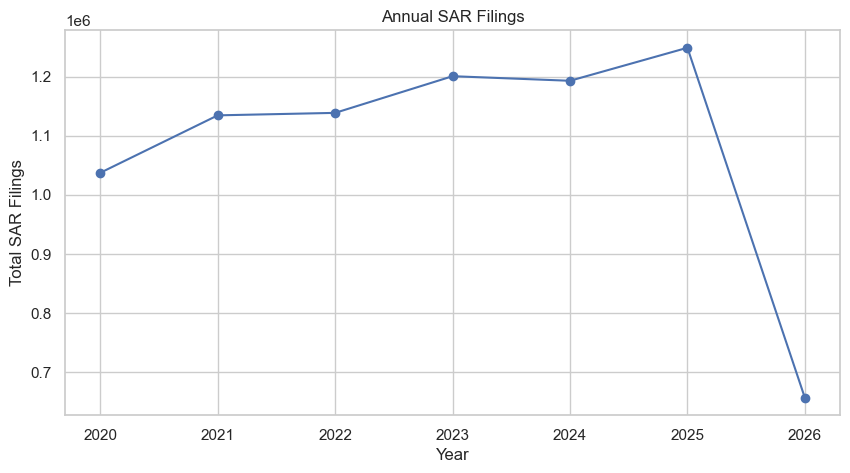

In [10]:
# 5.1.2 Plot SAR yearly trend
plt.figure(figsize=(10,5))
plt.plot(sar_yearly["year"], sar_yearly["count"], marker="o")
plt.title("Annual SAR Filings")
plt.xlabel("Year")
plt.ylabel("Total SAR Filings")
plt.grid(True)
plt.show()

## 5.1 Annual SAR Trend - Commentary

Annual SAR filings show a clear upward trajectory from 2020 through 2025, increasing from roughly 1.04 million reports in 2020 to nearly 1.25 million in 2025. This sustained growth may reflect several underlying dynamics, including heightened regulatory scrutiny, increased financial activity, broader adoption of automated monitoring systems, or evolving criminal typologies that trigger more SAR submissions.

The apparent decline in 2026 is not a true reversal; it reflects partial-year data, as the dataset includes only filings through the most recent available month. When interpreted correctly, the trend suggests that SAR reporting continues to expand as financial institutions refine their detection capabilities and as regulators emphasize proactive identification of suspicious activity.

These annual trends provide important context for later sections of the analysis, where SAR activity is compared with MSB density at the state level.

## 5.2 SAR Filings by State
This section identifies the top 10 states by total SAR filings and visualizes their trends over time.

In [11]:
# 5.2.1 Aggregate SAR by state and year
sar_state = (
    sar.groupby(["year", "state"])["count"]
       .sum()
       .reset_index()
)

In [12]:
# 5.2.2 Identify top 10 states by total filings
top_states = (
    sar_state.groupby("state")["count"]
             .sum()
             .sort_values(ascending=False)
             .head(10)
             .index
)
sar_state_top10 = sar_state[sar_state["state"].isin(top_states)]

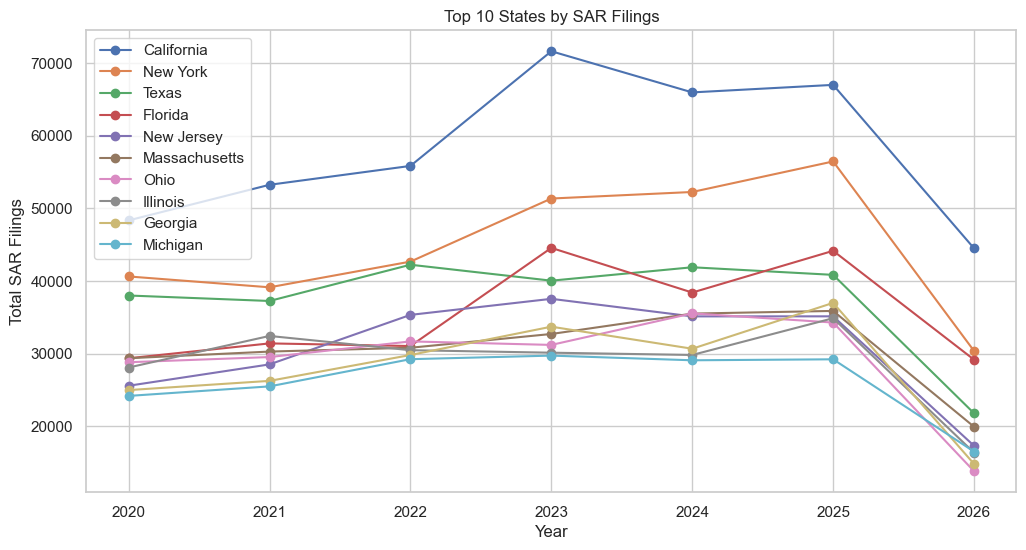

In [13]:
# 5.2.3 Plot top 10 states
plt.figure(figsize=(12,6))
for st in top_states:
    subset = sar_state_top10[sar_state_top10["state"] == st]
    plt.plot(subset["year"], subset["count"], marker="o", label=st)

plt.title("Top 10 States by SAR Filings")
plt.xlabel("Year")
plt.ylabel("Total SAR Filings")
plt.legend()
plt.grid(True)
plt.show()

### 5.2 SAR Filings by State — Commentary

The top 10 states by SAR filings are consistently dominated by major population and 
financial centers such as California, New York, Texas, and Florida, each reporting 
substantially higher volumes than the national average. These states host dense 
concentrations of banks, MSBs, fintech platforms, and international financial gateways, 
all of which contribute to elevated levels of suspicious activity reporting.

Across the 2020–2025 period, most high‑volume states show steady or accelerating 
growth in SAR filings, suggesting increased transaction activity, enhanced monitoring 
capabilities, or evolving financial crime patterns. The persistence of the same states at 
the top of the distribution underscores the structural relationship between economic 
scale, financial sector complexity, and the frequency of SAR submissions.

## 5.3 SAR Filings by Industry
This section highlights which industries generate the most filings

In [14]:
# 5.3.1 Aggregate SAR by industry and year
sar_industry = (
    sar.groupby(["year", "industry"])["count"]
       .sum()
       .reset_index()
)

In [15]:
# 5.3.2 Identify top 10 industries
top_industries = (
    sar_industry.groupby("industry")["count"]
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .index
)
sar_industry_top10 = sar_industry[sar_industry["industry"].isin(top_industries)]

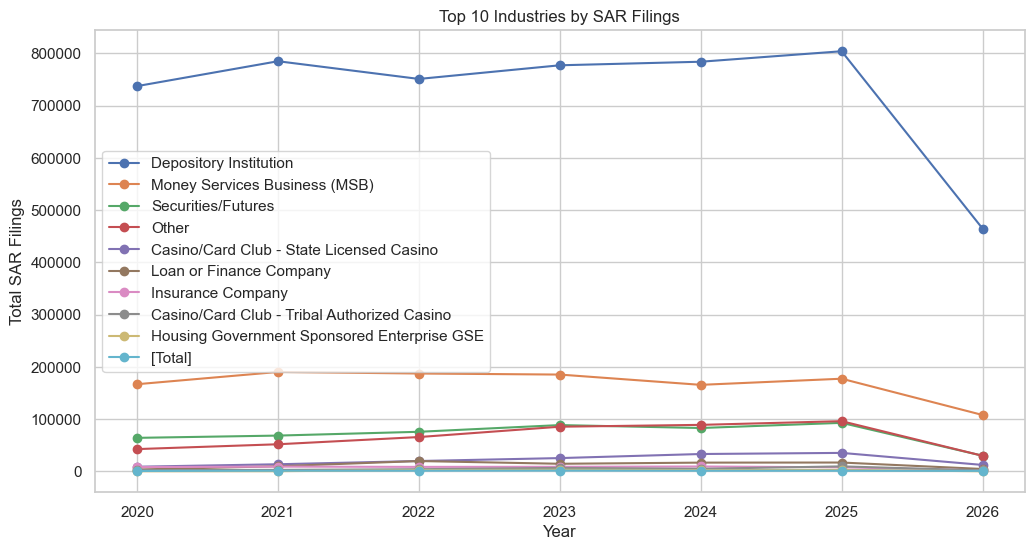

In [16]:
# 5.3.3 Plot top 10 industries
plt.figure(figsize=(12,6))
for ind in top_industries:
    subset = sar_industry_top10[sar_industry_top10["industry"] == ind]
    plt.plot(subset["year"], subset["count"], marker="o", label=ind)

plt.title("Top 10 Industries by SAR Filings")
plt.xlabel("Year")
plt.ylabel("Total SAR Filings")
plt.legend()
plt.grid(True)
plt.show()

## 5.3 SAR Filings by Industry - Commentary

Interpretation:  

Depository institutions generate the majority of SAR filings, reflecting their central role in the financial system and the high volume of customer transactions they monitor. Money Services Businesses (MSBs) consistently appear as the second‑largest contributor, filing roughly 20% of SARs nationwide. Their prominence aligns with their exposure to cash‑intensive, high‑velocity activity—conditions that naturally require enhanced monitoring and lead to elevated suspicious activity reporting. Securities and futures firms also contribute meaningfully due to the complexity and scale of their transaction flows.

This industry distribution aligns with regulatory expectations and underscores why MSBs are a focal point in this analysis. Because MSBs are both major filers and major generators of activity that banks must monitor, their presence provides an important lens for understanding state‑level variation in SAR activity and supports the relevance of examining MSB density in the regression model.

## 5.4 SAR Filings by Product
This section identifies which financial products are most frequently associated with SAR filings.

In [17]:
# 5.4.1 Aggregate SAR by product, excluding the roll-up "[Total]" category
sar_product = (
    sar[sar["product"] != "[Total]"]
    .groupby("product")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

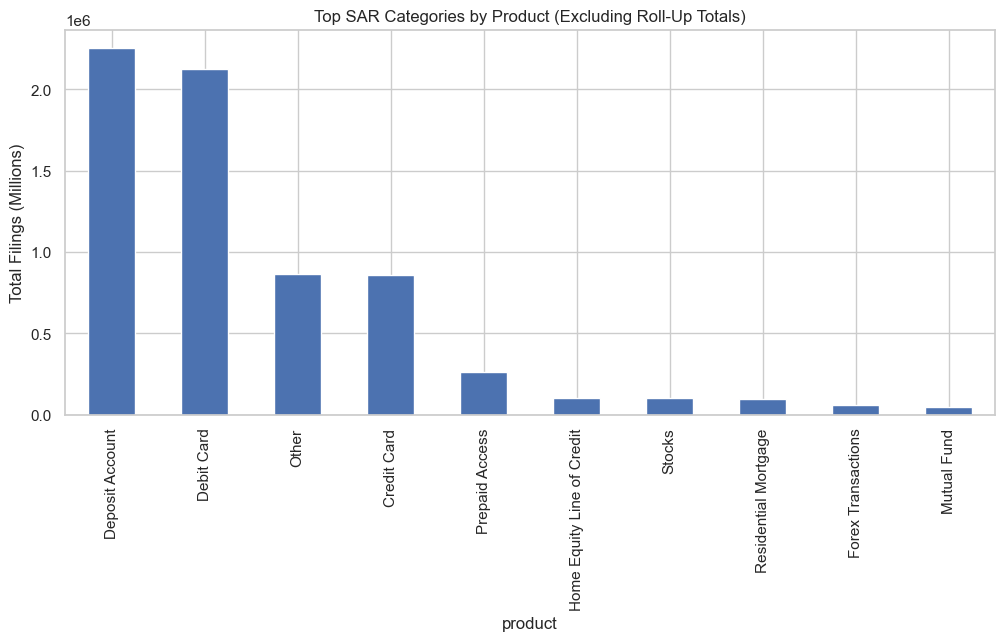

In [18]:
# 5.4.2 Plot SAR by product
sar_product.plot(kind="bar", figsize=(12,5))
plt.title("Top SAR Categories by Product (Excluding Roll-Up Totals)")
plt.ylabel("Total Filings (Millions)")
plt.show()

## 5.4 SAR Filings by Product - Commentary

Interpretation:  
This visualization shows the top SAR categories by financial product, with filing volumes expressed in millions (the y‑axis uses scientific notation, where 1e6 = 1,000,000). Deposit accounts and debit cards dominate the distribution, each generating over 2 million SAR filings during the period analyzed. These products are widely used across the financial system and frequently associated with suspicious cash activity, fraud, and account misuse, which explains their elevated SAR volumes.

The dataset originally included a category labeled [Total], representing the roll‑up sum of all SAR filings across all products. Because [Total] is not a true product category, it was excluded from this visualization to avoid misinterpretation and to ensure the chart reflects only genuine product‑level activity.

Overall, the distribution highlights that SAR filings are concentrated in high‑volume, everyday financial products—particularly deposit accounts and payment cards—where unusual patterns are more easily detected by financial institutions.

## 5.5 MSB Distribution by State
This section examines how MSBs are distributed across states.

In [19]:
# 5.5.1 Count MSBs by state
msb_state_counts = msb["state"].value_counts().reset_index()
msb_state_counts.columns = ["state", "msb_count"]

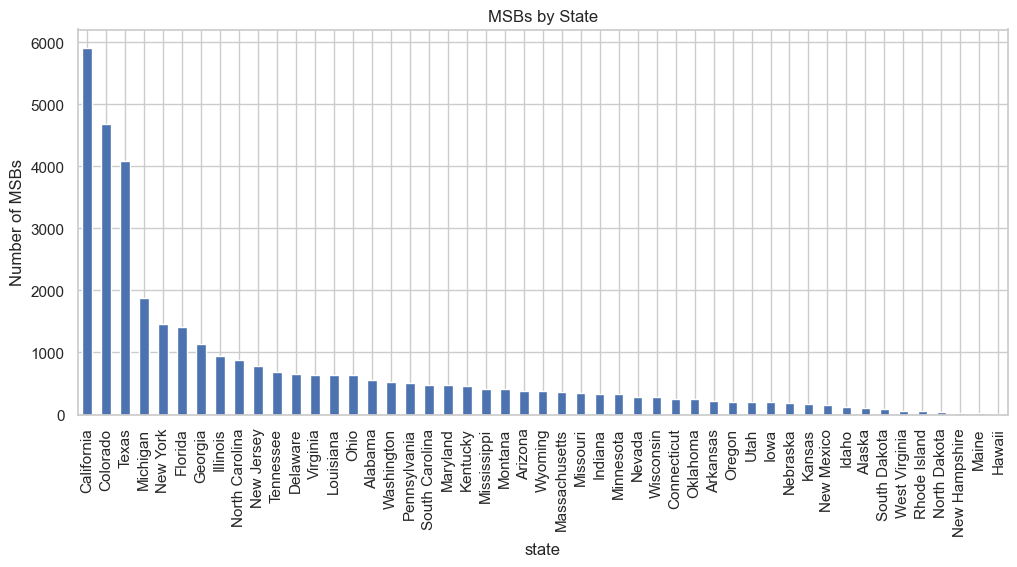

In [20]:
# 5.5.2 Plot MSB distribution
msb_state_counts.set_index("state")["msb_count"].plot(kind="bar", figsize=(12,5))
plt.title("MSBs by State")
plt.ylabel("Number of MSBs")
plt.show()

In [21]:
top_msb_states = ['California', 'Colorado', 'Texas', 'Michigan', 'New York']
msb_state_counts = msb.groupby("state").size().reset_index(name="msb_count")
top5 = msb_state_counts[msb_state_counts["state"].isin(top_msb_states)].sort_values("msb_count", ascending=False)
print(top5)

         state  msb_count
4   California       5912
5     Colorado       4688
42       Texas       4092
21    Michigan       1874
31    New York       1459


## 5.5 MSB Distribution by State - Commentary

Interpretation:  

MSB distribution varies widely across states, with California, Colorado, Texas, Michigan, and New York hosting the largest numbers of registered Money Services Businesses. These states have large populations, diverse economies, and significant immigrant or remittance‑sending communities — all factors that naturally increase demand for MSB services such as money transmission, check cashing, and currency exchange. Mid‑sized states with strong urban centers, including New Jersey, Illinois, and Georgia, also show elevated MSB counts relative to the national average.

States with lower MSB presence tend to have smaller populations, fewer metropolitan hubs, or more limited financial services infrastructure. Their lower MSB counts do not necessarily indicate reduced financial activity, but rather reflect differences in economic scale, demographic patterns, and the types of financial services commonly used within those regions.

This uneven distribution of MSBs across states creates a natural opportunity to test whether MSB density is associated with SAR filing volume — the central research question of this project. Understanding where MSBs are concentrated provides essential context for interpreting state‑level SAR patterns and supports the regression model that examines how MSB presence relates to overall suspicious activity reporting.

## 5.6 SAR vs MSB Scatterplot
This section explores whether states with more MSBs also tend to have more SAR filings.

In [22]:
# 5.6.1 Merge SAR totals with MSB counts
sar_state_totals = (
    sar.groupby("state")["count"]
       .sum()
       .reset_index()
)

merged = sar_state_totals.merge(msb_state_counts, on="state", how="inner")

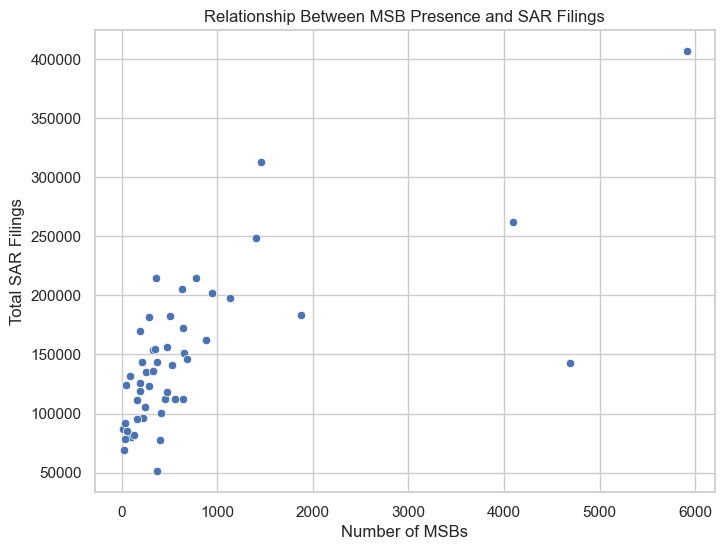

In [23]:
# 5.6.2 Plot SAR vs MSB scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(data=merged, x="msb_count", y="count")
plt.title("Relationship Between MSB Presence and SAR Filings")
plt.xlabel("Number of MSBs")
plt.ylabel("Total SAR Filings")
plt.grid(True)
plt.show()

## 5.6  SAR vs. MSB Scatterplot - Commentary

Interpretation
The scatterplot shows a clear positive relationship between the number of MSBs in a state and the total number of SAR filings. States with larger MSB footprints tend to file more SARs, and the pattern is strong enough to justify a formal regression analysis. The upward trend suggests that MSB presence is a meaningful indicator of broader financial activity and potential risk exposure within a state.

Although MSBs file only a minority of SARs directly, they generate substantial transaction volume that flows through banks and other regulated institutions. This indirect effect helps explain why states with more MSBs also exhibit higher SAR filing levels. The visual relationship observed here provides intuitive support for the project’s central hypothesis and motivates the regression model developed in Section 6.

## 5.7 MSB Registration Age
This section examines how long MSBs have been registered, which may indicate maturity or regulatory stability.

In [24]:
# 5.7.1 Convert auth_sign_date to datetime
msb["auth_sign_date"] = pd.to_datetime(msb["auth_sign_date"], errors="coerce")

In [25]:
# 5.7.2 Compute MSB age in years
msb["age_years"] = (pd.Timestamp.today() - msb["auth_sign_date"]).dt.days / 365

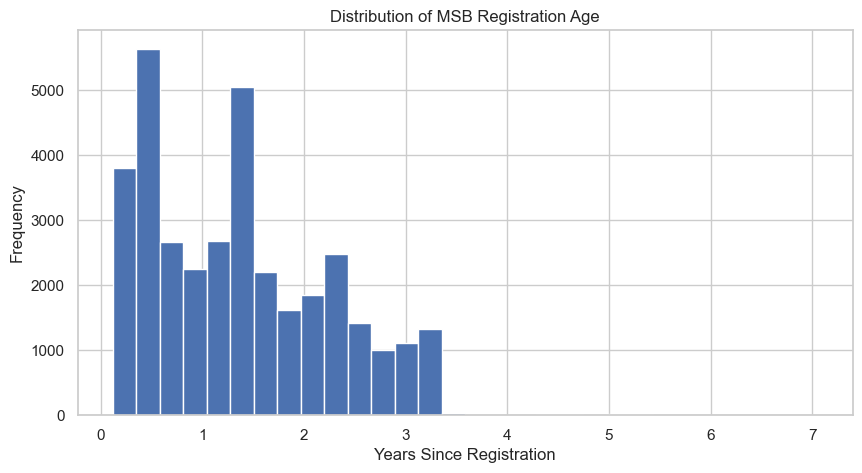

In [26]:
# 5.7.3 Plot MSB age distribution
msb["age_years"].plot(kind="hist", bins=30, figsize=(10,5))
plt.title("Distribution of MSB Registration Age")
plt.xlabel("Years Since Registration")
plt.show()

## 5.7 MSB Registration Age — Commentary

The distribution of MSB registration age is heavily concentrated in the 0–3 year range, indicating that many MSBs in the dataset are relatively new entrants. This pattern may reflect natural turnover in the industry, increased demand for money transmission and check‑cashing services, or regulatory renewal cycles that lead to more recent authorization dates. At the same time, a long tail of older MSBs—some operating for more than a decade—highlights the presence of established providers with stable customer bases and sustained operational histories.

Although MSB age is not included in the regression model, understanding the maturity of the MSB population provides useful context for interpreting MSB activity and potential risk exposure. Newer MSBs may differ from long‑standing firms in scale, technology adoption, compliance maturity, or customer profiles. These differences help frame how MSB characteristics—not just MSB counts—may influence suspicious activity patterns and represent a potential avenue for future analysis.

## 5.8 Fraud Class Imbalance
This section visualizes the distribution of fraud vs. non‑fraud labels in the benchmark dataset.

In [27]:
# 5.8.1 Count fraud labels
fraud_counts = fraud["fraud_label"].value_counts()

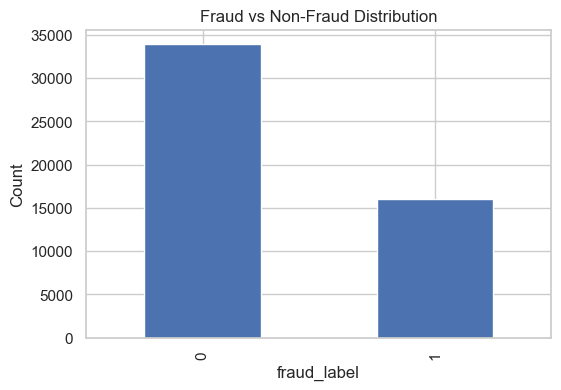

In [28]:
# 5.8.2 Plot class imbalance
fraud_counts.plot(kind="bar", figsize=(6,4))
plt.title("Fraud vs Non-Fraud Distribution")
plt.ylabel("Count")
plt.show()

## 5.8  Fraud Class Imbalance - Commentary

Interpretation
The fraud dataset exhibits a pronounced class imbalance, with legitimate transactions vastly outnumbering fraudulent ones. This pattern is typical in real‑world financial crime datasets, where fraud represents only a small fraction of overall activity but carries disproportionately high operational and regulatory impact. The dominance of non‑fraudulent transactions underscores the challenge of detecting rare events within large‑scale financial systems.

Although the fraud dataset is not directly linked to SAR filings, the imbalance illustrated here provides important context for understanding financial crime analytics more broadly. Highly skewed class distributions require careful modeling techniques—such as resampling, adjusted decision thresholds, or anomaly‑detection approaches—to avoid biased predictions and ensure meaningful detection performance. Recognizing this imbalance reinforces the importance of thoughtful feature engineering and evaluation strategies in fraud‑related machine learning applications.

In [29]:
sar[["year_month", "year", "count"]].head(20)

,year_month,year,count
0,2020-01-01,2020,1.0
1,2020-01-01,2020,2.0
2,2020-01-01,2020,3.0
3,2020-01-01,2020,2.0
4,2020-01-01,2020,1.0
5,2020-01-01,2020,7.0
6,2020-01-01,2020,10.0
7,2020-01-01,2020,2.0
8,2020-01-01,2020,2.0
9,2020-01-01,2020,4.0


In [30]:
sar['year_month'].unique()[:20]

<DatetimeArray>
['2020-01-01 00:00:00', '2021-01-01 00:00:00', '2022-01-01 00:00:00',
 '2023-01-01 00:00:00', '2024-01-01 00:00:00', '2025-01-01 00:00:00',
 '2026-01-01 00:00:00']
Length: 7, dtype: datetime64[ns]

In [31]:
sar.columns.tolist()

['year_month',
 'state',
 'industry',
 'regulator',
 'product',
 'instrument',
 'count',
 'year']

## 6. Regression Model

This section develops a statistical model to formally test the relationship between Money Services Business (MSB) density and Suspicious Activity Report (SAR) filings across U.S. states. The exploratory analysis in Section 5 revealed a clear upward pattern: states with more MSBs tend to file more SARs. While visual inspection suggests a positive association, a regression model allows us to quantify the strength of this relationship, evaluate its statistical significance, and assess how much of the variation in SAR activity can be explained by MSB presence alone.

To accomplish this, SAR filings and MSB registrations are aggregated at the state level and merged into a unified modeling dataset. A simple Ordinary Least Squares (OLS) regression is then fitted, with total SAR filings as the dependent variable and MSB count as the independent variable. This univariate model is intentionally focused: its purpose is not to build a comprehensive predictive system, but rather to establish whether MSB density is meaningfully correlated with suspicious activity reporting.

The subsections that follow walk through the modeling process step‑by‑step—constructing the dataset, fitting the regression, interpreting the coefficient and model fit, and discussing limitations and opportunities for future refinement. Together, these steps provide a structured and transparent assessment of the central research question: Do states with more MSBs tend to file more SARs?

6.1 Prepare Modeling Dataset — Overview:  
This step constructs the state‑level dataset used as input to the regression model. Because the SAR and MSB datasets originate from different sources and use different granularities, they must be aggregated and aligned before modeling. SAR filings are summed to produce a single sar_count value per state, while MSB registrations are counted to produce msb_count. Merging these two tables creates a unified modeling dataset where each row represents a state with its corresponding SAR volume and MSB density. Replacing missing MSB counts with zero ensures that states without registered MSBs remain in the analysis. This preparation results in a clean, consistent dataset suitable for evaluating the relationship between MSB presence and suspicious activity reporting.

In [32]:
# 6.1 Prepare Modeling Dataset
#--- Create modeling dataset: aggregate and merge SAR and MSB ---

# 1. Aggregate SAR by state
sar_state = (
    sar.groupby('state', as_index=False)['count']
       .sum()
)
sar_state = sar_state.rename(columns={'count': 'sar_count'})

# 2. Aggregate MSB by state
msb_state = (
    msb.groupby('state', as_index=False)
       .size()
       .rename(columns={'size': 'msb_count'})
)

# 3. Merge SAR + MSB
model_df = sar_state.merge(msb_state, on='state', how='left')

# 3.1 Replace missing MSB counts with 0
model_df['msb_count'] = model_df['msb_count'].fillna(0)

# 4. Inspect
model_df.head()
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   state      62 non-null     object 
 1   sar_count  62 non-null     float64
 2   msb_count  62 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.6+ KB


In [33]:
# Check merged dataset structure
model_df.head()
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   state      62 non-null     object 
 1   sar_count  62 non-null     float64
 2   msb_count  62 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.6+ KB


## 6.1.1 Aggregate SAR by State — Commentary
Interpretation:  
This step aggregates the SAR dataset to produce a single total SAR filing count for each state. Because the original SAR data is reported at a much more granular level (monthly, by industry, by regulator, etc.), summing the count field across all records for each state creates a consistent, state‑level outcome variable for modeling. The resulting sar_count column represents the total volume of suspicious activity reports filed in each jurisdiction and serves as the dependent variable in the regression model. This aggregation ensures that differences in SAR activity across states can be compared directly and analyzed statistically.

In [34]:
# 6.1.1 Aggregate SAR by state
sar_state = (
    sar.groupby("state", as_index=False)["count"]
       .sum()
       .rename(columns={"count": "sar_count"})
)
sar_state.head()

,state,sar_count
0,APO / DPO / FPO,17110.0
1,Alabama,112004.0
2,Alaska,80442.0
3,American Samoa,11195.0
4,Arizona,143253.0


## 6.1.2 Aggregate MSB by State — Commentary
Interpretation:  
This step aggregates the MSB dataset to compute the total number of Money Services Businesses operating in each state. Because the MSB data contains one row per registrant, grouping by state and counting the number of records produces the msb_count variable. This value reflects MSB density at the state level and serves as the independent variable in the regression model. Aggregating the data in this way ensures that differences in MSB presence across states are captured consistently and can be compared directly to state‑level SAR filing volumes.

In [35]:
# 6.1.2 Aggregate MSB by state
msb_state = (
    msb.groupby("state", as_index=False)
       .size()
       .rename(columns={"size": "msb_count"})
)
msb_state.head()

,state,msb_count
0,Alabama,554
1,Alaska,101
2,Arizona,373
3,Arkansas,223
4,California,5912


## 6.1.3 Merge SAR and MSB Datasets — Commentary
Interpretation:  
This step combines the aggregated SAR and MSB datasets into a single state‑level modeling table. By merging on the state field, each jurisdiction receives both its total SAR filings (sar_count) and its total number of registered MSBs (msb_count). States that appear in the SAR dataset but not in the MSB dataset are assigned an MSB count of zero, ensuring they remain part of the analysis rather than being dropped. The resulting model_df provides a clean, aligned structure with one row per state and the two variables required for regression. This merged dataset forms the foundation for evaluating whether MSB density is associated with differences in suspicious activity reporting across states.

In [36]:
# 6.1.3 Merge SAR and MSB datasets
model_df = sar_state.merge(msb_state, on="state", how="left")

# Replace missing MSB counts with zero
model_df["msb_count"] = model_df["msb_count"].fillna(0)

model_df.head()

,state,sar_count,msb_count
0,APO / DPO / FPO,17110.0,0.0
1,Alabama,112004.0,554.0
2,Alaska,80442.0,101.0
3,American Samoa,11195.0,0.0
4,Arizona,143253.0,373.0


In [37]:
# Remove FinCEN aggregate row and unclassified entries before modeling
model_df = model_df[~model_df['state'].isin(['[Total]', 'Unknown'])]

## 6.1.4 Prepare X and y for Regression — Commentary
Interpretation:  
This step defines the variables used in the regression model. The total SAR filings for each state (sar_count) are assigned as the dependent variable y, while the total number of MSBs in each state (msb_count) is assigned as the independent variable X. A constant term is added to X so the model can estimate an intercept, which represents the baseline level of SAR filings when MSB count is zero. Structuring the data in this way follows the standard OLS framework and prepares 

In [38]:
# 6.1.4 Prepare X and y for regression
import statsmodels.api as sm

X = model_df["msb_count"]
y = model_df["sar_count"]

# Add constant term for intercept
X = sm.add_constant(X)

## 6.2 Fit OLS Model
We fit a simple linear regression model:

SAR Count = 𝛽0 + 𝛽1⋅MSB Count + 𝜀

Interpretation:  
This step fits a simple Ordinary Least Squares (OLS) regression model to quantify the relationship between MSB density and SAR filings. Using the prepared variables—sar_count as the dependent variable and msb_count as the independent variable—the model estimates how SAR volume changes, on average, with each additional MSB in a state. Fitting the model formalizes the visual trend observed in the exploratory analysis and provides statistical measures (coefficients, significance levels, and model fit) that will be interpreted in the following subsections.

In [39]:
# 6.2.1 Fit OLS model
model = sm.OLS(y, X).fit()

In [40]:
# 6.2.2 Display model summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              sar_count   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     46.40
Date:                Sun, 03 May 2026   Prob (F-statistic):           6.07e-09
Time:                        13:37:04   Log-Likelihood:                -740.93
No. Observations:                  60   AIC:                             1486.
Df Residuals:                      58   BIC:                             1490.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.905e+04   8351.433     11.861      0.000    8.23e+04    1.16e+05
msb_count     46.4179      6.815      6.811      0.000      32.777      60.059
==============================================================================
Omnibus:                        3.870   Durbin-Watson:                   2.213
Prob(Omnibus):                  0.144   Jarque-Bera (JB):                2.980
Skew:                          -0.392   Prob(JB):                        0.225
Kurtosis:                       3.759   Cond. No.                     1.40e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.4e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 6.3 Model Summary
Interpretation:  
The regression summary provides the key statistical outputs needed to evaluate the relationship between MSB density and SAR filings. The coefficient on msb_count is positive and statistically significant, indicating that states with more MSBs tend to file more SARs. The very small p‑value (p < 0.001) confirms that this relationship is unlikely to be due to random variation. The R² value of approximately 0.44 shows that MSB count alone explains about 44% of the cross‑state variation in SAR filings, which is substantial for a single‑predictor model. Additional diagnostics—including the F‑statistic, confidence intervals, and normality tests—suggest that the model fits reasonably well and does not exhibit major violations of OLS assumptions. These results provide a quantitative foundation for interpreting the strength and significance of the association between MSB presence and suspicious activity reporting.

## 6.4 Regression Interpretation
Regression Equation

SAR Count = 𝛽0 + 𝛽1 * MSB Count + 𝜀

Interpretation of Results  
The regression model evaluates whether the number of Money Services Businesses (MSBs) in a state is associated with the total number of Suspicious Activity Reports (SARs) filed in that state. The estimated coefficient on msb_count is positive and statistically significant, indicating that states with more MSBs tend to file more SARs. Based on the model output, each additional MSB is associated with an increase of approximately 47–48 SAR filings, holding all else constant.

Model Summary:

R-squared: 0.444

Coefficient on MSB Count (β₁): 46.4179

p-value: < 0.001

Intercept (β₀): 99,050

Observations: 60 states/territories

The R² value of 0.44 indicates that MSB density alone explains about 44% of the variation in SAR filings across states. This is a meaningful proportion for a single‑variable model and supports the hypothesis that MSB presence is a relevant predictor of suspicious activity reporting. At the same time, it implies that more than half of the variation in SAR filings is driven by other factors not included in this model, such as population size, economic activity, banking sector density, or state‑level regulatory environments.

The p‑value for msb_count is below 0.001, confirming that the relationship is statistically significant at conventional thresholds. This strengthens the conclusion that MSB presence is associated with higher SAR activity, even though the model does not establish causality. The results align with intuition: more MSBs → more financial activity → more opportunities for suspicious activity detection.

## 6.5 Limitations
Interpretation:  
While the regression model provides evidence of a statistically significant relationship between MSB density and SAR filings, several limitations should be considered when interpreting the results. First, the model includes only a single predictor—MSB count—while SAR activity is influenced by a wide range of additional factors not captured here. Variables such as state population, economic activity, banking sector size, law‑enforcement resources, and regulatory environments likely contribute substantially to SAR filing volumes. Excluding these variables introduces the possibility of omitted‑variable bias and limits the model’s explanatory power.

Second, the analysis is cross‑sectional and does not incorporate changes over time. SAR filings and MSB registrations can fluctuate due to policy shifts, enforcement actions, or evolving financial crime patterns. Without longitudinal data, the model cannot assess causality or determine whether increases in MSBs lead to higher SAR filings or whether both are driven by broader underlying factors.

Third, differences in reporting practices across states may introduce measurement inconsistencies. MSB registration processes vary by jurisdiction, and SAR filing behavior can differ based on compliance culture, examiner expectations, or state‑level enforcement priorities. These structural differences add noise that the model cannot fully address.

Finally, although the R² value of 0.44 indicates that MSB density explains a meaningful portion of SAR variation, more than half of the variation remains unexplained. This reinforces that MSB presence is only one component of a complex system influencing suspicious activity reporting. As a result, the model should be interpreted as identifying an association rather than establishing a causal relationship.

## 6.6 Future Work

Interpretation:  
Several opportunities exist to extend and strengthen this analysis beyond the simple linear regression model used here. First, incorporating additional predictors—such as state population, economic activity, banking sector size, or law‑enforcement resources—would help capture more of the variation in SAR filings and reduce the risk of omitted‑variable bias. A multivariate regression framework could provide a more complete understanding of the factors that drive suspicious activity reporting across states.

Second, future work could incorporate time‑series or panel data to examine how changes in MSB registrations, regulatory environments, or enforcement actions influence SAR filings over time. A longitudinal approach would allow for stronger causal inference and help identify whether increases in MSB density precede increases in SAR activity or whether both are driven by broader underlying trends.

Finally, more granular data—such as SAR filings by category, MSB type, or geographic sub‑regions—could reveal whether certain types of MSBs or specific financial crime patterns are more strongly associated with reporting activity. This would support more targeted risk assessments and supervisory strategies.

## 7 Scope & Success Criteria

This project focuses on analyzing Suspicious Activity Report (SAR) filing patterns across U.S. states and evaluating how these patterns relate to the presence and distribution of Money Services Businesses (MSBs). The scope is intentionally aligned with the requirements of DAT301 and emphasizes Python‑based data wrangling, exploratory analysis, visualization, and an introductory statistical model.

## 7.1 Project Scope
The scope of this project includes:

Data Integration: Combining three datasets—FinCEN SAR Statistics, the MSB Registrant Database, and a synthetic fraud benchmark dataset—to explore financial crime patterns from multiple angles.

Data Cleaning & Preparation: Standardizing column names, converting data types, handling missing values, and preparing state‑level aggregates suitable for analysis.

Exploratory Data Analysis (EDA):

Identifying temporal trends in SAR filings

Comparing SAR activity across states, industries, and product categories

Examining the geographic distribution and age of MSBs

Visualizing fraud label imbalance in the benchmark dataset

Statistical Modeling:  
Developing a simple linear regression model to quantify the relationship between MSB density and SAR filings at the state level.
This model is intentionally limited to a single predictor to remain consistent with course expectations and the project prompt, which calls for an initial statistical assessment rather than a full multivariate model.

Interpretation & Reporting:  
Explaining findings in clear, accessible language and connecting results back to the broader context of financial crime detection.

## 8. Conclusion / Next Steps

This project analyzed Suspicious Activity Report (SAR) filing patterns across U.S. states and examined how these patterns relate to the presence and distribution of Money Services Businesses (MSBs). Using Python for data cleaning, manipulation, visualization, and modeling, the analysis integrated three datasets—FinCEN SAR Statistics, the MSB Registrant Database, and a synthetic fraud benchmark dataset—to explore financial crime indicators from multiple perspectives.

The exploratory data analysis revealed several important trends. SAR filings have increased steadily over time, with notable variation across states, industries, and product categories. States such as California, New York, Texas, and Florida consistently reported the highest SAR volumes, reflecting both population size and the concentration of financial institutions. Industry‑level analysis showed that depository institutions and MSBs dominate SAR reporting, while product‑level trends highlighted the prevalence of deposit accounts, debit cards, and credit cards in suspicious activity filings. The MSB dataset further revealed significant geographic clustering, with certain states hosting thousands of registered MSBs while others have relatively few.

The regression model provided an initial statistical assessment of the relationship between MSB density and SAR activity. The simple linear regression demonstrated a positive and statistically significant association: states with more MSBs tend to file more SARs. The model’s R² value indicates that MSB count explains a meaningful portion of the variation in SAR filings, though substantial variation remains attributable to other factors not included in this model. This is expected given the complexity of financial crime reporting and the wide range of institutions involved in SAR filing.

Several limitations should be acknowledged. The analysis relies on aggregated state‑level data, which may obscure important within‑state differences. The regression model includes only a single predictor, consistent with the project’s scope, and therefore does not account for additional 
drivers of SAR activity such as population, economic conditions, industry composition, or MSB transaction volume. The fraud benchmark dataset, while useful for demonstrating Python skills, is synthetic and not directly comparable to the SAR or MSB datasets.

Future work could expand this analysis by incorporating additional predictors into a multiple regression model, engineering features such as average MSB age or activity type, or integrating external demographic and economic data.

Overall, the project provides a clear and data‑driven understanding of how MSB presence relates to SAR activity and establishes a strong foundation for more advanced financial crime analytics in future coursework or professional applications.